- **Import dependencies**

In [2]:
%reset -f
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch.nn.functional as F
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

- **Load the data**

In [31]:
# Load the spline results
with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)

- **Extract the spline objects**

In [32]:
# Extract relevant objects
at_pred_spline = res_spline["at_pred"]
basis_cols = res_spline["basis_cols"]
x_train_spline = res_spline["x_train_spline"]
x_test_spline = res_spline["x_test_spline"]
data_spline_full = res_spline["data_spline_full"]

- **Prepare group function**

In [33]:
# Prepare group function
def prepare_groups_spline(x):

    # Sort the dates
    dates = np.sort(x["quote_date"].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:

        # Extract the group
        group = x[x["quote_date"] == date]

        # Append to list
        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **IV prediction function**

In [34]:
# Predict the IV function
def predict_iv(Z_groups, at_pred):

    # Create empty list
    log_iv_pred = []

    # Loop over the number of groups
    for t in range(len(Z_groups)):

        # Extract regressors and coefficients
        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        # Compute predictions
        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    # Concatenate results and exponentiate
    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    # Return the results
    return log_iv_pred, iv_pred

- **Split the training and testing sample for bucketed data**

In [35]:
# Training sample
dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(x_train_spline)

# Testing sample
dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(x_test_spline)

# Number of training dates
n_train_dates_spline = len(dates_train_spline)

- **Split the training and testing sample for full contract data**

In [36]:
# Training sample
x_train_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_train_spline)
].copy()

# Testing sample
x_test_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_test_spline)
].copy()

# Ensure fixed quote date order for training sample
x_train_spline_full_nn["quote_date"] = pd.Categorical(
    x_train_spline_full_nn["quote_date"],
    categories=dates_train_spline,
    ordered=True)

# Ensure fixed quote date order for testing sample
x_test_spline_full_nn["quote_date"] = pd.Categorical(
    x_test_spline_full_nn["quote_date"],
    categories=dates_test_spline,
    ordered=True)

# Sort the values
x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()
x_test_spline_full_nn = x_test_spline_full_nn.sort_values("quote_date").copy()

# Convert back to string
x_train_spline_full_nn["quote_date"] = x_train_spline_full_nn["quote_date"].astype(str)
x_test_spline_full_nn["quote_date"] = x_test_spline_full_nn["quote_date"].astype(str)

- **Compute spline prior predictions on training sample**

In [ ]:
# Prepare groups
dates_train_full_spline_nn, y_groups_train_full_spline_nn, Z_groups_train_full_spline_nn = prepare_groups_spline(
    x_train_spline_full_nn)

# COmpute predictions
log_iv_prior_train_full_spline_nn, iv_prior_train_full_spline_nn = predict_iv(
    Z_groups_train_full_spline_nn,
    at_pred_spline[:, :len(dates_train_full_spline_nn)])

- **COmpute spline prior on full-contract data**

In [ ]:
# Prepare groups
dates_test_full_spline_nn, y_groups_test_full_spline_nn, Z_groups_test_full_spline_nn = prepare_groups_spline(
    x_test_spline_full_nn)

# Compute predictions
log_iv_prior_test_full_spline_nn, iv_prior_test_full_spline_nn = predict_iv(
    Z_groups_test_full_spline_nn,at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline_nn)
    ])


- **Create DataFrame for neural network**

In [ ]:
# Copy the DF
x_train_nn = x_train_spline_full_nn.copy()

# Store prior predictions
x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn

# Floor the predictions
iv_prior_floor = 0.02
x_train_nn["iv_prior_safe"] = x_train_nn["iv_prior"].clip(lower=iv_prior_floor)

# Compute residuals
x_train_nn["residual_target"] = (x_train_nn["iv_fun"] - x_train_nn["iv_prior"])
x_train_nn["abs_error_prior"] = np.abs(x_train_nn["residual_target"])



- **Clean the training data**

In [ ]:
# Clean data
x_train_nn = x_train_nn.replace([np.inf, -np.inf], np.nan)
x_train_nn = x_train_nn.dropna(
    subset=["M", "T", "iv_fun", "iv_prior", "iv_prior_safe", "residual_target", "moneyness_group", "maturity_group"]).copy()
x_train_nn = x_train_nn.copy()

# Specify the features
feature_cols = ["M", "T", "iv_prior_safe"]

# Print diagnostics
print("Number of full non-bucketed training observations:", len(x_train_nn))
print("Average spline residual in full training sample:", x_train_nn["residual_target"].mean())
print("Spline prior MAE on full non-bucketed training sample:", x_train_nn["abs_error_prior"].mean())

# **2. Neural network**

In [ ]:
# Define neural network class
class ResidualNN(nn.Module):

    # Setup function
    def __init__(self, n_features):

        # Initialize nn.Module class
        super().__init__()

        # Create hidden layers of the neural network
        self.hidden = nn.Sequential(
            nn.Linear(n_features, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh())

        # Linear output layer
        self.output = nn.Linear(80, 1)

        # Call the custom weight initialization function
        self.initialize_weights()

    # Weight initialization function
    def initialize_weights(self):

        # Loop over all parts of the model
        for layer in self.modules():

            # Apply initialization to linear layers
            if isinstance(layer, nn.Linear):

                # Get number of inputs and outputs of the layer
                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                # Standard deviation for random initialization
                std = (fan_in + fan_out) ** (-0.5)

                # Initialize weights and biases randomly
                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

        # Set the final layers weights and bias to zero
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    # Define what happens when data is passed through the model
    def forward(self, x):

        # Pass input features through three hidden layers
        x = self.hidden(x)

        # Pass hidden output through final layer to get one number
        log_omega_multiplier = self.output(x)

        # Exponentiate the output
        omega_multiplier = torch.exp(log_omega_multiplier)

        # return the result
        return omega_multiplier

- **Prepare the training data**

In [ ]:
# Specify dependent variable and features
X = x_train_nn[feature_cols].to_numpy(dtype=float)
y = x_train_nn[["iv_fun"]].to_numpy(dtype=float)
iv_prior = x_train_nn[["iv_prior_safe"]].to_numpy(dtype=float)
T = x_train_nn[["T"]].to_numpy(dtype=float)

# Create a scaler object and standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert NumPy arrays to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
iv_prior_tensor = torch.tensor(iv_prior, dtype=torch.float32)
T_tensor = torch.tensor(T, dtype=torch.float32)

# Specify dataset
dataset = TensorDataset(X_tensor,y_tensor,iv_prior_tensor,T_tensor)

# Create mini-batch iterator for training
loader = DataLoader(dataset, batch_size=65536, shuffle=True)


- **Training the network**

In [ ]:
# Create the neural network
model = ResidualNN(n_features=len(feature_cols))

# Set initial learning rate
initial_lr = 0.001
current_lr = initial_lr

# Create the optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-6)

# Training settings
max_epochs = 400
lr_check_window = 100
stop_check_window = 200
required_improvement = 0.003

# Create empty list
loss_history = []

# Loop over the epochs
for epoch in range(max_epochs):

    # At the start, reset total loss
    total_loss = 0.0

    # Get batch from DataLoader
    for X_batch, y_batch, iv_prior_batch, T_batch in loader:

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Pass the features through the NN
        omega_multiplier = model(X_batch)

        # Compute the spline-implied total variance and apply prediction
        omega_prior = iv_prior_batch ** 2 * T_batch
        omega_pred = omega_multiplier * omega_prior

        # Convert total variance back to IV
        iv_pred = torch.sqrt(
            torch.clamp(
                omega_pred / torch.clamp(T_batch, min=1e-8),
                min=1e-12))

        # Compute RMSE
        rmse = torch.sqrt(
            torch.mean((y_batch - iv_pred) ** 2))

        # Compute MAPE
        mape = torch.mean(
            torch.abs(y_batch - iv_pred)
            / torch.clamp(y_batch, min=1e-8))

        # Combine the loss functions
        loss = rmse + mape

        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        # Track the total loss
        total_loss += loss.item()

    # Average epoch loss
    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    # Print every 50 epochs the number, average loss and current LR
    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    # Check for enough improvement
    if epoch > 0 and epoch % lr_check_window == 0:

        # Get the old loss and compute percentage improvements
        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        # If improvement less than 0.3%, reduce LR
        if improvement < required_improvement:

            # Half the LR
            current_lr = current_lr / 2

            # Actually update the optimizer's learing rate
            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            # Print the change
            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    # Check every 200 epochs, whether training should stop
    if epoch > 0 and epoch % stop_check_window == 0:

        # Compare losses
        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        # Stop training loop early
        if improvement < required_improvement:
            print("Stopping: loss did not improve enough")
            break



- **Apply NN correction to training sample**

In [ ]:
# Put model in evaluation mode
model.eval()

# Disable gradient tracking
with torch.no_grad():

    # Feed training inputs into trained NN
    omega_multiplier_train = model(X_tensor).numpy().flatten()

# Store the NN multiplier in training DF
x_train_nn["omega_multiplier_nn"] = omega_multiplier_train

# Convert spline IV prediction into spline total variance
omega_prior_train = (
    x_train_nn["iv_prior_safe"].to_numpy(dtype=float) ** 2
    * x_train_nn["T"].to_numpy(dtype=float))

# Apply NN correction multiplier to spline total variance
omega_nn_train = (
    x_train_nn["omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_train)

# Convert corrected total variance back into implied volatility
x_train_nn["iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_train
        / np.maximum(x_train_nn["T"].to_numpy(dtype=float), 1e-8),
        1e-12))

# Clip the corrected IV and compute the correction in IV terms
x_train_nn["iv_nn"] = x_train_nn["iv_nn"].clip(lower=1e-6)
x_train_nn["residual_nn"] = (x_train_nn["iv_nn"] - x_train_nn["iv_prior"])

# Compute the absolute error
x_train_nn["abs_error_nn"] = np.abs(
    x_train_nn["iv_fun"] - x_train_nn["iv_nn"])

# Print the results
print("NN corrected MAE on full non-bucketed training sample:", x_train_nn["abs_error_nn"].mean())
print("Average omega multiplier on full training sample:", x_train_nn["omega_multiplier_nn"].mean())
print("Minimum omega multiplier on full training sample:", x_train_nn["omega_multiplier_nn"].min())
print("Maximum omega multiplier on full training sample:", x_train_nn["omega_multiplier_nn"].max())

- **Apply correction to the test sample**

In [ ]:
# Make a copy of the test sample
x_test_nn = x_test_spline_full_nn.copy()

# Clip the prior IV and clean invalid observations
x_test_nn["iv_prior"] = iv_prior_test_full_spline_nn
x_test_nn["iv_prior_safe"] = x_test_nn["iv_prior"].clip(lower=iv_prior_floor)
x_test_nn = x_test_nn.replace([np.inf, -np.inf], np.nan)
x_test_nn = x_test_nn.dropna(
    subset=["M","T","iv_fun","iv_prior","iv_prior_safe","moneyness_group","maturity_group"]).copy()

# Correction applied to all regions
x_test_nn["residual_nn"] = 0.0
x_test_nn["omega_multiplier_nn"] = 1.0
x_test_nn["iv_nn"] = x_test_nn["iv_prior"]

# Choose which rows get corrected
correction_mask = np.ones(len(x_test_nn), dtype=bool)

# Select feature columns for all test rows
X_test_region = x_test_nn.loc[
    correction_mask,
    feature_cols
].to_numpy(dtype=float)

# Scale the test features
X_test_region_scaled = scaler.transform(X_test_region)
X_test_region_tensor = torch.tensor(X_test_region_scaled, dtype=torch.float32)

# Put the model into evaluation mode
model.eval()

# Turn off gradient tracking
with torch.no_grad():

    # Feed test features into NN
    x_test_nn.loc[correction_mask, "omega_multiplier_nn"] = (
        model(X_test_region_tensor)
        .numpy()
        .flatten())

# COmpute spline total variance
omega_prior_test = (
    x_test_nn.loc[correction_mask, "iv_prior_safe"].to_numpy(dtype=float) ** 2
    * x_test_nn.loc[correction_mask, "T"].to_numpy(dtype=float))

# Apply NN multiplier to total variance
omega_nn_test = (
    x_test_nn.loc[correction_mask, "omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_test)

# Convert corrected total variance back to IV
x_test_nn.loc[correction_mask, "iv_nn"] = np.sqrt(
    np.maximum(omega_nn_test / np.maximum(x_test_nn.loc[correction_mask, "T"].to_numpy(dtype=float), 1e-8), 1e-12))
x_test_nn["iv_nn"] = x_test_nn["iv_nn"].clip(lower=1e-6)

# Compute NN correction in IV units
x_test_nn["residual_nn"] = (
    x_test_nn["iv_nn"] - x_test_nn["iv_prior"])

# Compute testing errors
x_test_nn["abs_error_prior"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_prior"])
x_test_nn["abs_error_nn"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_nn"])

# Print the results
print("Spline prior MAE on full non-bucketed testing data:", x_test_nn["abs_error_prior"].mean())
print("NN total-variance multiplicative-corrected MAE on full non-bucketed testing data, all regions:", x_test_nn["abs_error_nn"].mean())
print("Average predicted residual by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["residual_nn"].mean())
print("Average predicted omega multiplier by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["omega_multiplier_nn"].mean())
print("OOS MAE by moneyness group:")
print(x_test_nn.groupby("moneyness_group")[["abs_error_prior", "abs_error_nn"]].mean())
print("OOS MAE by maturity group:")
print(x_test_nn.groupby("maturity_group")[["abs_error_prior", "abs_error_nn"]].mean())

- **Create heatmap**

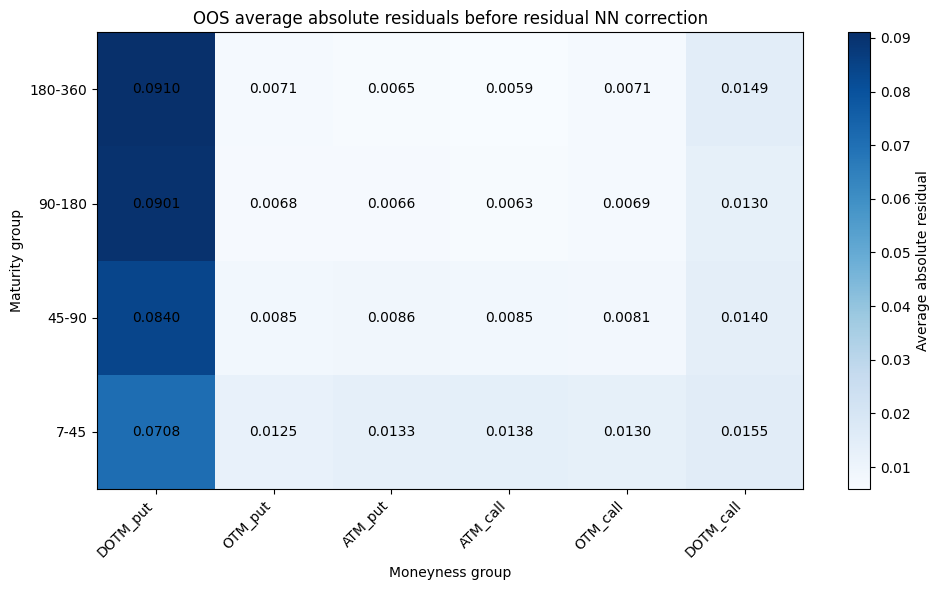

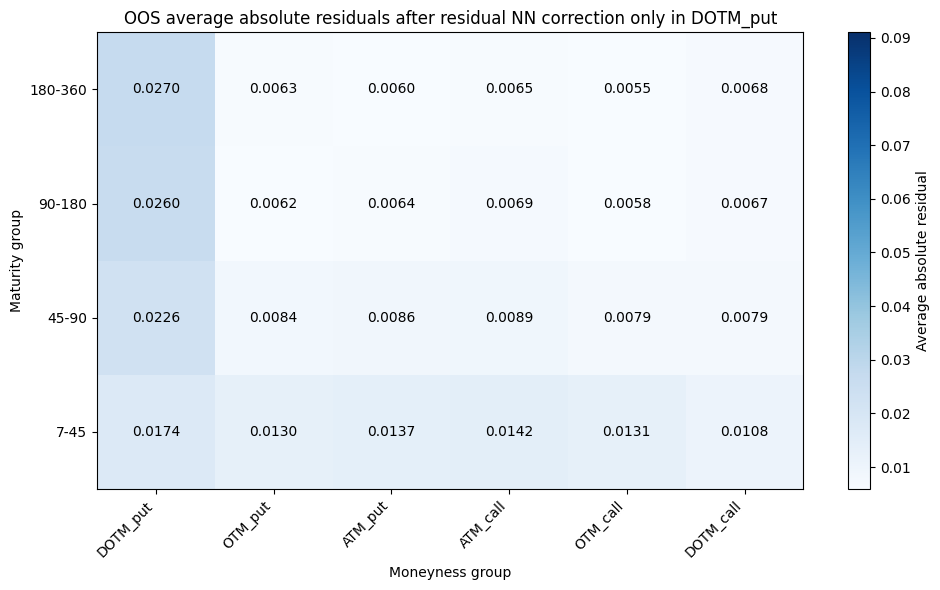

moneyness_group,DOTM_put,OTM_put,ATM_put,ATM_call,OTM_call,DOTM_call
maturity_group,,,,,,
7-45,0.017447,0.013020,0.013662,0.014218,0.013138,0.010793
45-90,0.022614,0.008408,0.008643,0.008904,0.007890,0.007867
90-180,0.025981,0.006182,0.006384,0.006901,0.005759,0.006663
180-360,0.026952,0.006261,0.006013,0.006542,0.005510,0.006836


In [10]:
# Heatmap function
def make_oos_nn_heatmap(data_heatmap, value_col, title, ax=None, show=True, vmin=None, vmax=None):

    # Moneyness and maturity orders
    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    # Copy the data
    data_heatmap = data_heatmap.copy()

    # Ensure fixed order
    data_heatmap["maturity_group"] = pd.Categorical(
        data_heatmap["maturity_group"],
        categories=maturity_order,
        ordered=True)

    # Ensure fixed order
    data_heatmap["moneyness_group"] = pd.Categorical(
        data_heatmap["moneyness_group"],
        categories=moneyness_order,
        ordered=True)

    # Create heatmap table
    heatmap_table = data_heatmap.pivot_table(
        values=value_col,
        index="maturity_group",
        columns="moneyness_group",
        aggfunc="mean",
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    # Customize plotting environment
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    # Draw the actual heatmap
    im = ax.imshow(heatmap_table, aspect="auto", cmap="Blues", vmin=vmin, vmax=vmax)

    # Write numeric values inside the heatmap

    # Loop over the rows
    for i in range(heatmap_table.shape[0]):

        # Loop over the columns
        for j in range(heatmap_table.shape[1]):

            # Get the corresponding value
            value = heatmap_table.iloc[i, j]

            # Check if value is missing
            if pd.notna(value):
                label = f"{value:.4f}"
            else:
                label = ""

            # Place the label in the correct spot
            ax.text(j, i, label, ha="center", va="center")

    # Invert the y-axis
    ax.invert_yaxis()

    # Customize labels
    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha="right")
    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)
    ax.set_xlabel("Moneyness group")
    ax.set_ylabel("Maturity group")
    ax.set_title(title)

    # Set colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Average absolute residual")

    # Plot the results
    if show:
        fig.tight_layout()
        plt.show()

    # Return the results
    return heatmap_table

# Create prior heatmap
heatmap_oos_prior = make_oos_nn_heatmap(x_test_nn,value_col="abs_error_prior",title="OOS average absolute residuals before residual NN correction")

# Ensure common scale
vmin_common = heatmap_oos_prior.min().min()
vmax_common = heatmap_oos_prior.max().max()

# Create NN heatmap
heatmap_oos_nn = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_nn",
    title="OOS average absolute residuals after residual NN correction only in DOTM_put",
    vmin=vmin_common,
    vmax=vmax_common)

# Plot the result
heatmap_oos_nn

- **Store the results**

In [5]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

# Store the results
with open("/Users/euanbronsky/PyCharmMiscProject/x_test_nn.pkl", "rb") as f:
    res_nn = pickle.load(f)

x_test_nn = res_nn['x_test_nn']

- **Create surface plots**

# **No-arbitrage**
---------------------------------

In [5]:
# Penalty function
def penalty_formulas(M, omega, omega_M, omega_T, omega_MM, eps=1e-8):

    # Clip omega for stability
    omega_safe = torch.clamp(omega, min=eps)

    # Calendary penalty
    calendar_penalty = torch.mean(
        torch.relu(-omega_T))

    # Butterfly condition
    butterfly_condition = (
        (1.0 - M * omega_M / (2.0 * omega_safe)) ** 2
        - (omega_M / 4.0) * (1.0 / omega_safe + 0.25)
        + 0.5 * omega_MM)

    # Butterfly penalty
    butterfly_penalty = torch.mean(
        torch.relu(-butterfly_condition))

    # Asymptotic penalty
    asymptotic_penalty = torch.mean(
        torch.abs(omega_MM))

    # Return the penalties
    return calendar_penalty, butterfly_penalty, asymptotic_penalty

In [22]:
nn_predictions = {
    'x_test_nn': x_test_nn,
}

with open("/Users/euanbronsky/PyCharmMiscProject/x_test_nn.pkl", "wb") as f:
    pickle.dump(nn_predictions, f)

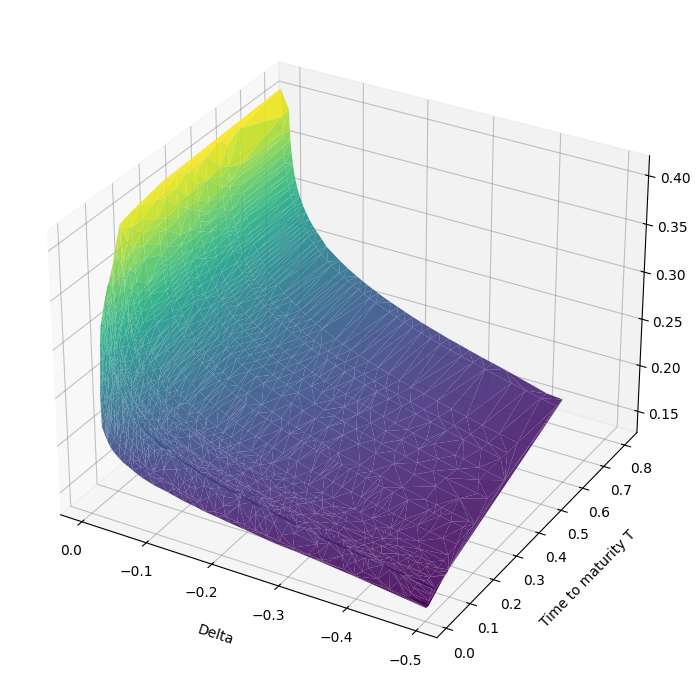

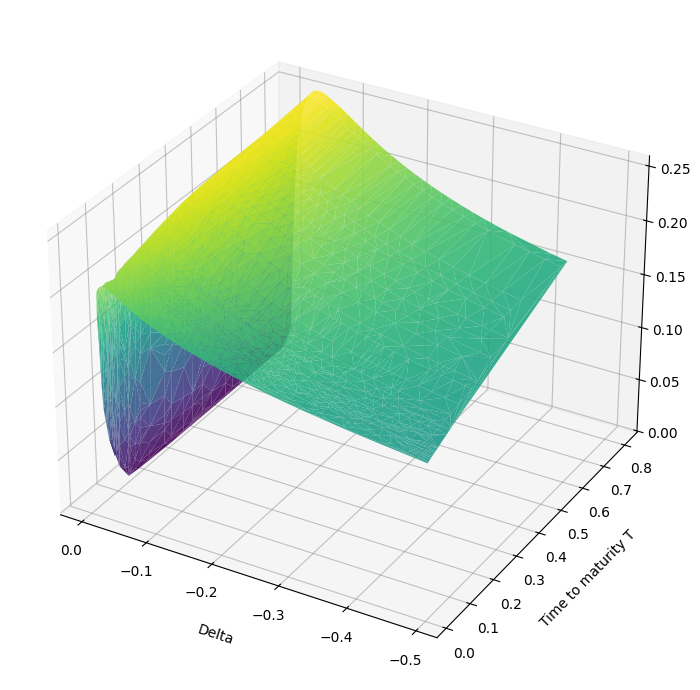

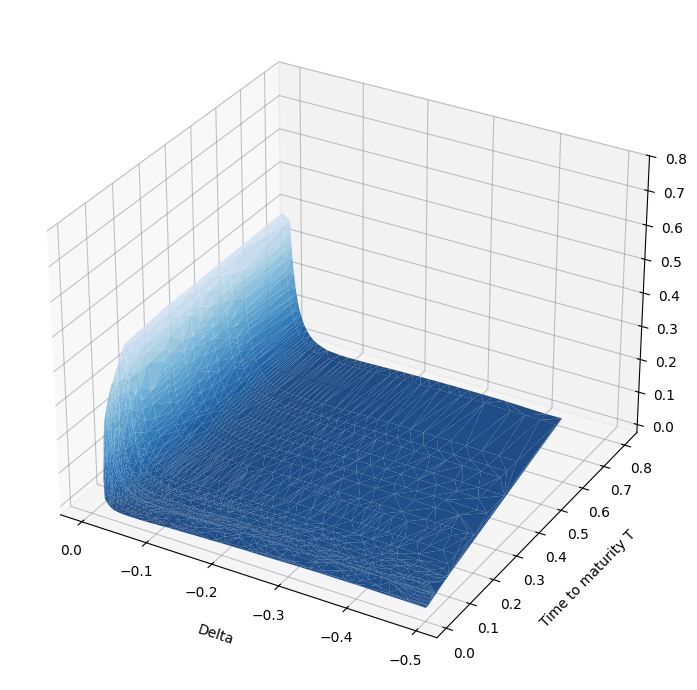

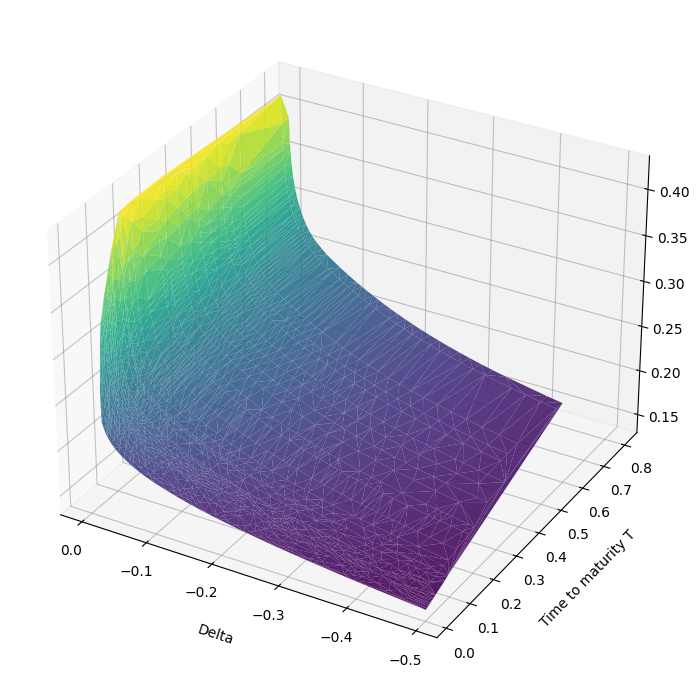

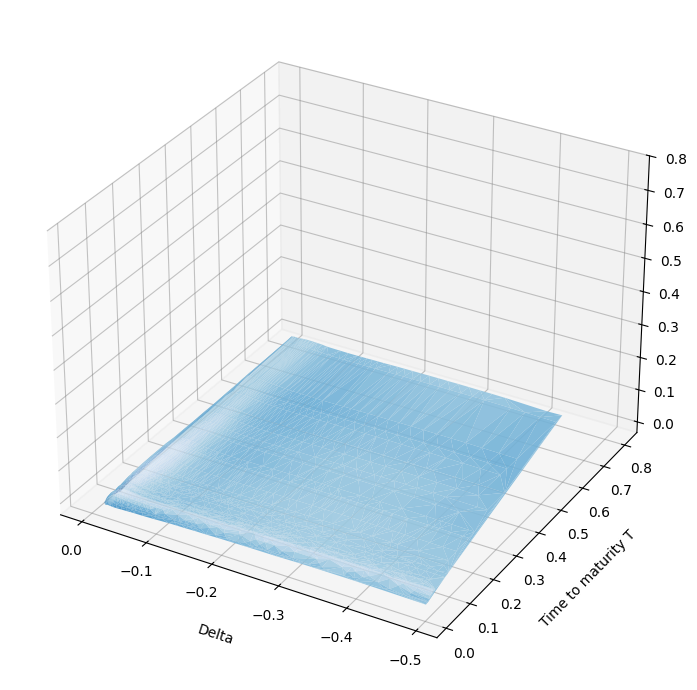

In [6]:
# Specify dates
plot_date = pd.Timestamp("2019-06-12").date()

# Filter observations for the plot date
surface_date = x_test_nn[
    pd.to_datetime(x_test_nn["quote_date"]).dt.date.eq(plot_date)
].copy()

# Keep only the put options
surface_date = surface_date[
    surface_date["moneyness_group"].isin(["DOTM_put", "OTM_put", "ATM_put"])
].copy()

# Compute prior residual
surface_date["residual_prior"] = (
    surface_date["iv_fun"] - surface_date["iv_prior"]
)

# Compute corrected residual
surface_date["residual_nn_corrected"] = (
    surface_date["iv_fun"] - surface_date["iv_nn"]
)

# Custom color map
blues_no_white = LinearSegmentedColormap.from_list(
    "blues_no_white",
    cm.Blues_r(np.linspace(0.02, 0.82, 256))
)


# Plotting function
def plot_trisurf_surface(data, value_col, zlabel, zmin=None, zmax=None,
                         cmap="viridis", save_path=None):

    # Specify the plotting data
    plot_data = data[["delta_fun", "T", value_col]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna().copy()

    # x, y, z axis
    x = plot_data["delta_fun"].to_numpy(dtype=float)
    y = plot_data["T"].to_numpy(dtype=float)
    z = plot_data[value_col].to_numpy(dtype=float)

    # Plotting environment
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # 3D surface
    surf = ax.plot_trisurf(
        x, y, z,
        cmap=cmap,
        edgecolor="none",
        antialiased=True,
        alpha=0.9
    )

    # Adjust labels
    ax.set_xlabel("Delta", labelpad=10)
    ax.set_ylabel("Time to maturity T", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.invert_xaxis()

    # Custom gridlines
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)

    # Set vertical axis limits
    if zmin is not None or zmax is not None:
        ax.set_zlim(bottom=zmin, top=zmax)

    # Tight layout
    plt.tight_layout()

    # Save figure
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    # Plot the results
    plt.show()


# Plot the observed IV surface
plot_trisurf_surface(
    surface_date,
    "iv_fun",
    "Implied volatility",
    save_path="/Users/euanbronsky/Downloads/surface_observed_put_iv_2019_06_12.png"
)

# Plot spline prior IV surface
plot_trisurf_surface(
    surface_date,
    "iv_prior",
    "Implied volatility",
    save_path="/Users/euanbronsky/Downloads/surface_spline_prior_put_iv_2019_06_12.png"
)

# Plot prior residual surface
plot_trisurf_surface(
    surface_date,
    "residual_prior",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white,
    save_path="/Users/euanbronsky/Downloads/surface_residual_before_nn_2019_06_12.png"
)

# Plot corrected IV surface
plot_trisurf_surface(
    surface_date,
    "iv_nn",
    "Implied volatility",
    save_path="/Users/euanbronsky/Downloads/surface_nn_corrected_put_iv_2019_06_12.png"
)

# Plot corrected residual surface
plot_trisurf_surface(
    surface_date,
    "residual_nn_corrected",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white,
    save_path="/Users/euanbronsky/Downloads/surface_residual_after_nn_2019_06_12.png"
)

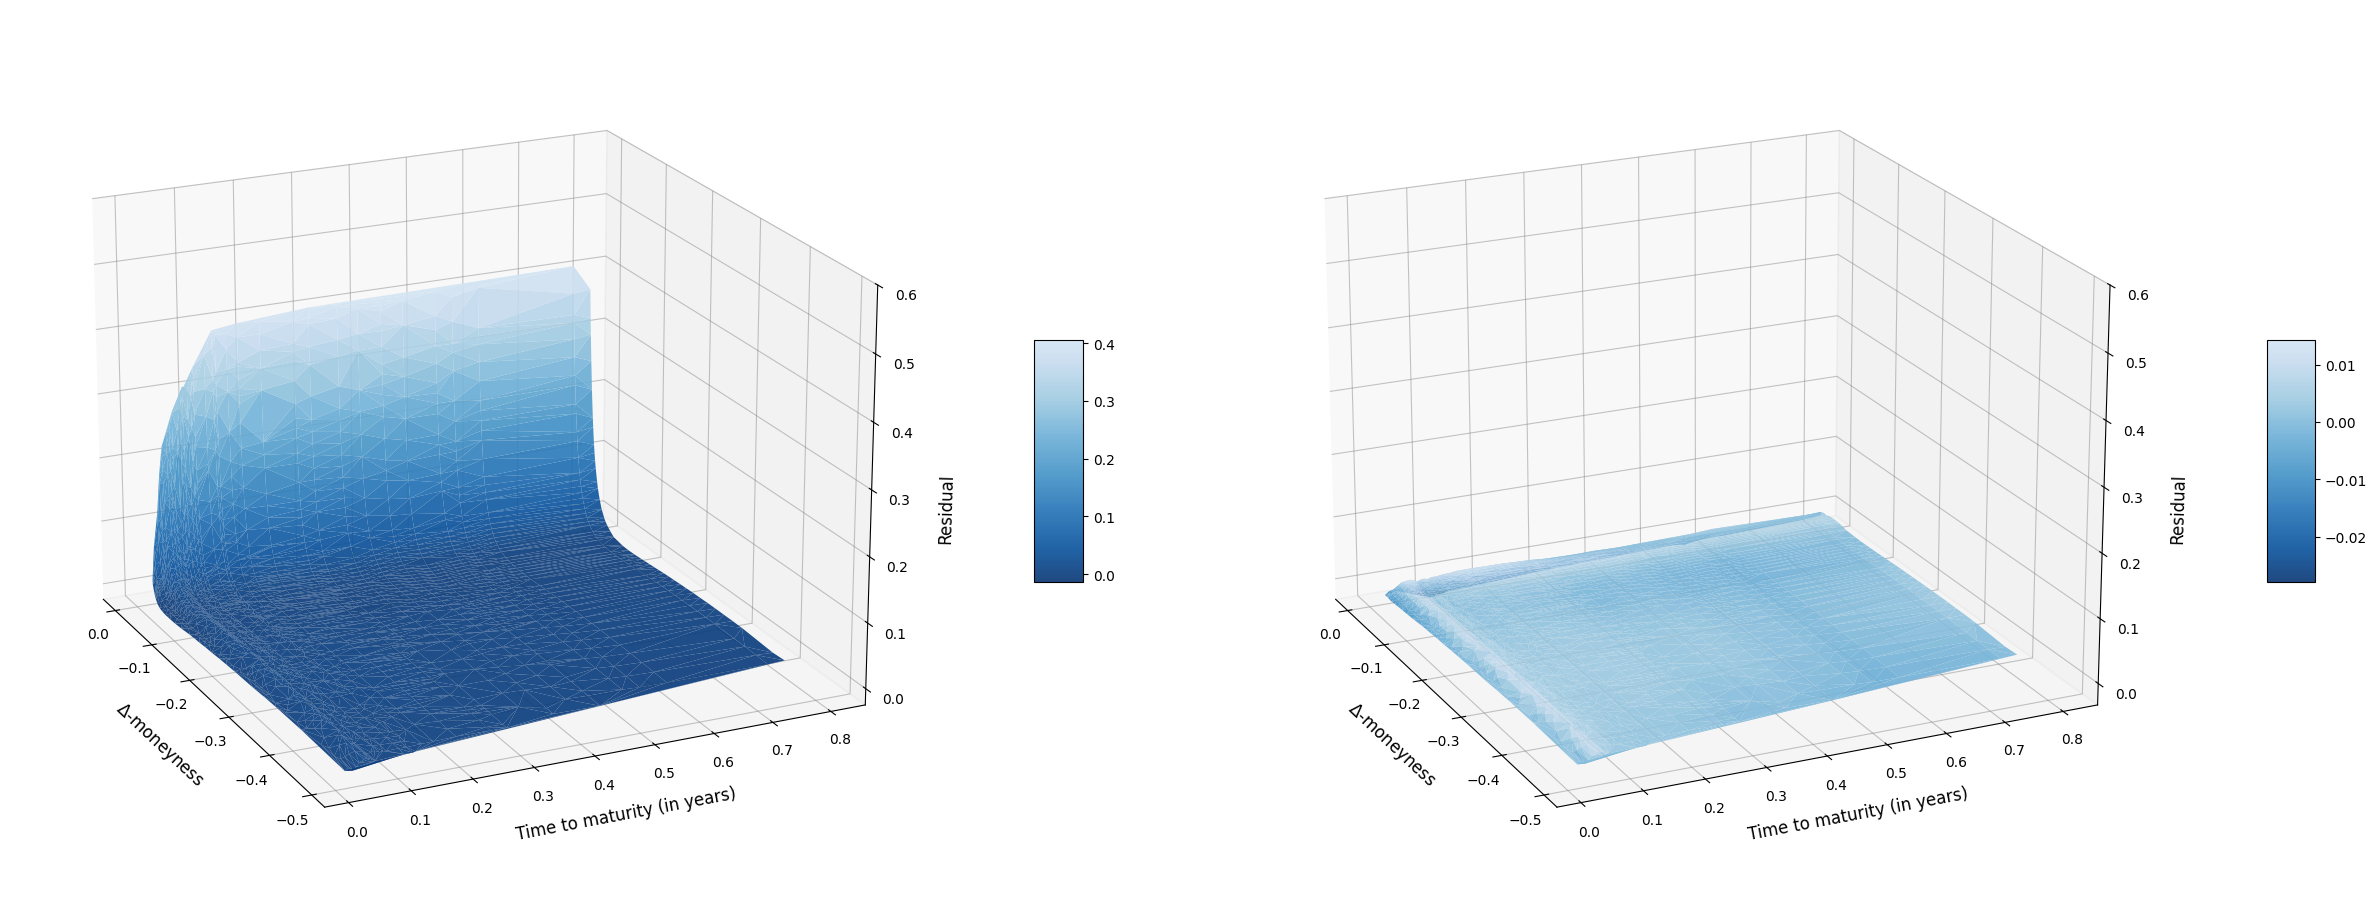

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(25, 10), subplot_kw={"projection": "3d"})
fig.subplots_adjust(wspace=3)

d1 = surface_date[["delta_fun", "T", "residual_prior"]].dropna()
surf1 = axes[0].plot_trisurf(d1["delta_fun"], d1["T"], d1["residual_prior"],
                             cmap=blues_no_white, edgecolor="none", alpha=0.9,
                             antialiased=True)
#axes[0].set_title("Before NN")
axes[0].set_xlabel(r"$\Delta$-moneyness", labelpad=10, fontsize = 12)
axes[0].set_ylabel("Time to maturity (in years)", labelpad=10, fontsize = 12)
axes[0].set_zlabel("Residual", labelpad=10, fontsize = 12)
axes[0].set_zlim(top=0.6)
axes[0].invert_xaxis()

d2 = surface_date[["delta_fun", "T", "residual_nn_corrected"]].dropna()
surf2 = axes[1].plot_trisurf(d2["delta_fun"], d2["T"], d2["residual_nn_corrected"],cmap=blues_no_white, edgecolor="none", alpha=0.9,
                             antialiased=True)
#axes[1].set_title("After NN")
axes[1].set_xlabel(r"$\Delta$-moneyness", labelpad=10, fontsize = 12)
axes[1].set_ylabel("Time to maturity (in years)", labelpad=10, fontsize = 12)
axes[1].set_zlabel("Residual", labelpad=10, fontsize = 12)
axes[1].set_zlim(top=0.6)
axes[1].invert_xaxis()

for ax in axes:
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.view_init(elev=20, azim=-25)

fig.colorbar(surf1, ax=axes[0], shrink=0.25, aspect=5, pad=0.1)
fig.colorbar(surf2, ax=axes[1], shrink=0.25,aspect=5, pad=0.1)

plt.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/resid.surfaces.png",bbox_inches="tight", dpi=300)
plt.show()